In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_percentage_error, r2_score

import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col ='Month', parse_dates=True)

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


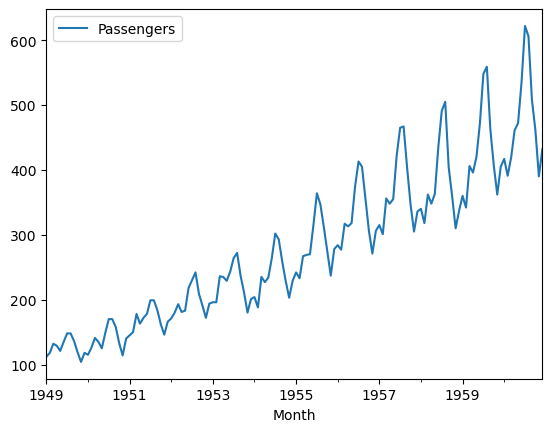

In [4]:
df.plot();

# working without differencing

In [5]:
df['LogPassengers'] = np.log(df['Passengers'])

In [6]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [30]:
series =  df['LogPassengers'].to_numpy() # converting this to numpy array since it is easy to index

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T] # returns from t to t + T -1
    y = series[t+T] # returns t+T
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (134, 10) Y.shape (134,)


In [39]:
''' Y is one step forecast'''

' Y is one step forecast'

In [34]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [48]:
''' the above way is wrong - since it leads to data leakage in test set and evaluation might lead to incorrect answers'''
'''' this is because the actual target label in the test set for each row appears as the 10th (last) feature in the next row of test set''' 

"' this is because the actual target label in the test set for each row appears as the 10th (last) feature in the next row of test set"

In [35]:
lr = LinearRegression()
lr.fit(Xtrain, Ytrain)
lr.score(Xtrain, Ytrain)

0.9599443783339898

In [36]:
lr.score(Xtest, Ytest)

0.6910953044565618

In [37]:
''' train r2 very good but test r2 score is not that good'''

' train r2 very good but test r2 score is not that good'

In [38]:
train_idx = df.index <= train.index[-1]
test_idx = ~ train_idx
train_idx[:T] = False # 1st T values are not predictable since model is trained to predict basis last T values

In [40]:
Xtrain.shape

(122, 10)

In [44]:
lr.predict(Xtrain).shape # it is predicting starting from the 11th value from the rawest "dataset

(122,)

In [43]:
train.shape

(132, 2)

In [49]:
#1-step forecast
df.loc[train_idx, 'LR_1step_train'] = lr.predict(Xtrain) # the prediction from the ml model is predicting the 11th value
df.loc[test_idx, 'LR_1step_test'] = lr.predict(Xtest)

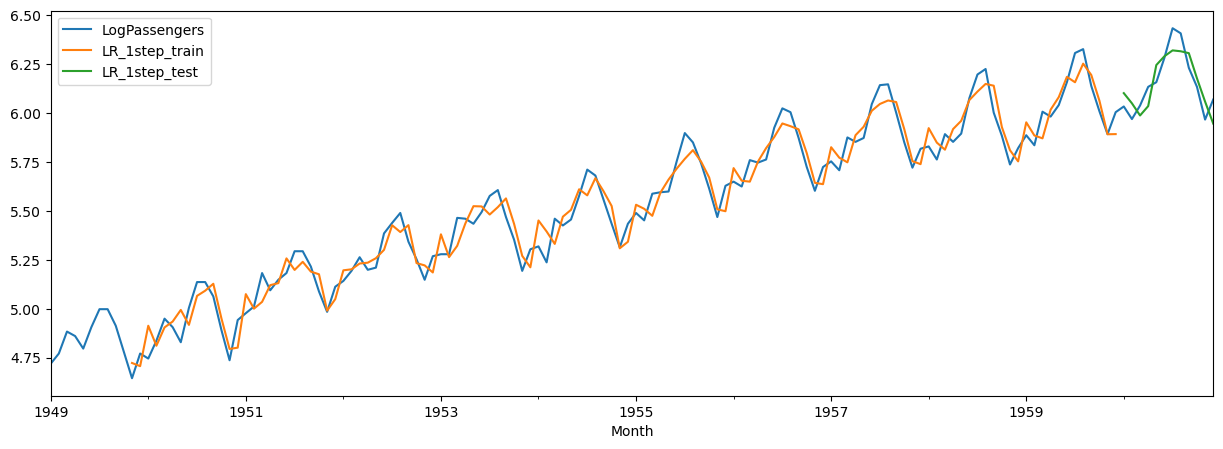

In [50]:
df[['LogPassengers','LR_1step_train','LR_1step_test']].plot(figsize =(15,5));

In [52]:
'''model is still underestimating the peak, even though there is data leakage in the test set
data leakage happenning since the target actual label in the test set is the last feature in the next row of data'''

'model is still underestimating the peak, even though there is data leakage in the test set\ndata leakage happenning since the target actual label in the test set is the last feature in the next row of data'

In [53]:
Xtest[0]

array([6.00635316, 5.98141421, 6.04025471, 6.15697899, 6.30627529,
       6.32614947, 6.13772705, 6.00881319, 5.89164421, 6.00388707])

In [85]:
# multi step forecast
multistep_predictions = []

#first test input
last_x = Xtest[0] # an array of 10 input values for test set

while len(multistep_predictions) < Ntest:
    p = lr.predict(last_x.reshape(1,-1))[0] # since last_x is just one element, the shape gets messed up, we are changing the shape to 1*T 
    #scikit learn accepts data in the shape N*T only
    # at the end putting [0] since we want numeric output and not the array output

    # update the predictions list
    multistep_predictions.append(p)

    # make the new input 
    last_x = np.roll(last_x, -1) #[ 1 2 3 4 5] => [2 3 4 5 1] doing it this way since we cant delete or append anything to an array
    last_x[-1] = p # using the predictions from the previous horizon to make prediction for the next horizon

In [89]:
''' the above is the correct method of multistep - since it is never seeing the actual target label. for the next horizon, it is 
using the previous predicted value of previous horizon'''
''' the above implementation is how statsmodels does it when we call model_res.forecast(Ntest)'''

' the above implementation is how statsmodels does it when we call model_res.forecast(Ntest)'

In [87]:
multistep_predictions

[np.float64(6.101198006227475),
 np.float64(6.112320666149664),
 np.float64(6.108175612308672),
 np.float64(6.081886058282398),
 np.float64(6.169742315703275),
 np.float64(6.281951437766923),
 np.float64(6.338334707010836),
 np.float64(6.28092141071876),
 np.float64(6.155061800731537),
 np.float64(6.090944070213975),
 np.float64(6.094248655139369),
 np.float64(6.155634785967001)]

In [88]:
df.loc[test_idx, 'LR_multistep'] = multistep_predictions

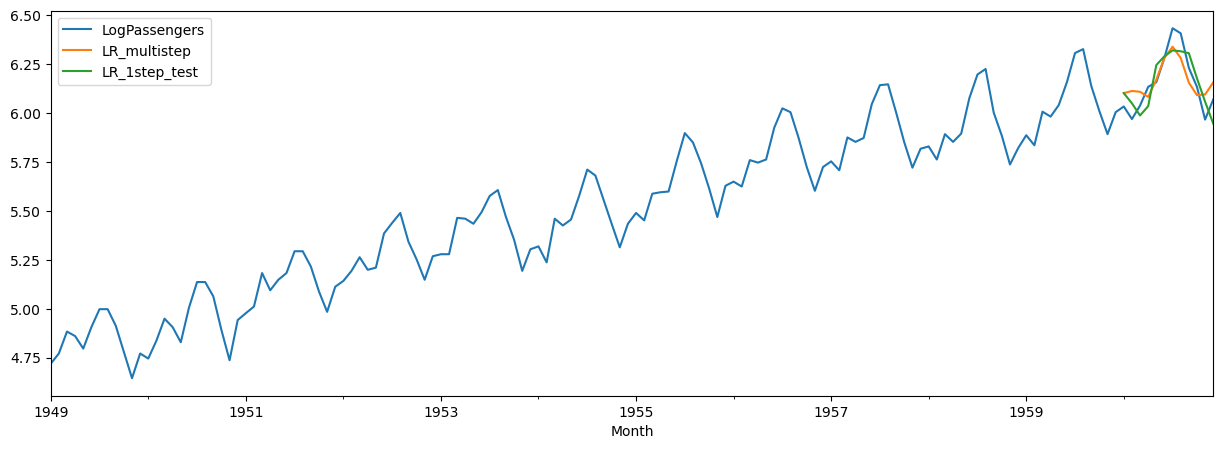

In [90]:
# plot 1 step and multistep forecast
df[['LogPassengers','LR_multistep','LR_1step_test']].plot(figsize = (15,5));

In [91]:
'''multi step is slightly worse but it is expected since for predicting t+2, t+1 is a prediction and not actuals which we used in 1 step'''

'multi step is slightly worse but it is expected since for predicting t+2, t+1 is a prediction and not actuals which we used in 1 step'

In [96]:
# making multi-output supervised dataset

series =  df['LogPassengers'].to_numpy()

Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx - Ty + 1):
    x = series[t:t+Tx]  
    y = series[t+Tx:t+Tx+Ty]  
    X.append(x)
    Y.append(y)
    # 1st x will have data inputs from 0 to 9 # 1st y will have data inputs from 10 to 21
    # 2nd x will have data inputs from 1 to 10 # 2nd y will have data inputs from 11 to 22

X = np.array(X).reshape(-1,Tx)
Y = np.array(Y).reshape(-1,Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

# converting this into numpy array since scikit learn only takes numpy array as an input
    

X.shape (123, 10) Y.shape (123, 12)


In [102]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [103]:
lr = LinearRegression()
lr.fit(Xtrain_m, Ytrain_m)
lr.score(Xtrain_m, Ytrain_m)

0.9734607773512528

In [106]:
''' although the r2 values shows improvement, but this is misleading since outputs repeat multiple times in diff rows 
example
- y1, y2, y3 in 1st rows and y2, y3, y4 in 2nd row'''

' although the r2 values shows improvement, but this is misleading since outputs repeat multiple times in diff rows \nexample\n- y1, y2, y3 in 1st rows and y2, y3, y4 in 2nd row'

In [105]:
lr.score(Xtest_m, Ytest_m)

C:\Users\VARUN\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

In [107]:
''' nan = not a number '''

' nan = not a number '

In [108]:
'''r2 denominator calculates variance from mean of diff samples, but since only 1 sample, SST is undefined '''

'r2 denominator calculates variance from mean of diff samples, but since only 1 sample, SST is undefined '

In [115]:
r2_score(lr.predict(Xtest_m).flatten(), Ytest_m.flatten())

0.801874967671522

In [116]:
'''this is an alternative way of calculating r2, this shows iimprovement. also note that the y labels in test hasnt been seen by the model yet'''

'this is an alternative way of calculating r2, this shows iimprovement. also note that the y labels in test hasnt been seen by the model yet'

In [112]:
df.loc[test_idx, 'LR_multioutput'] = lr.predict(Xtest_m).flatten()

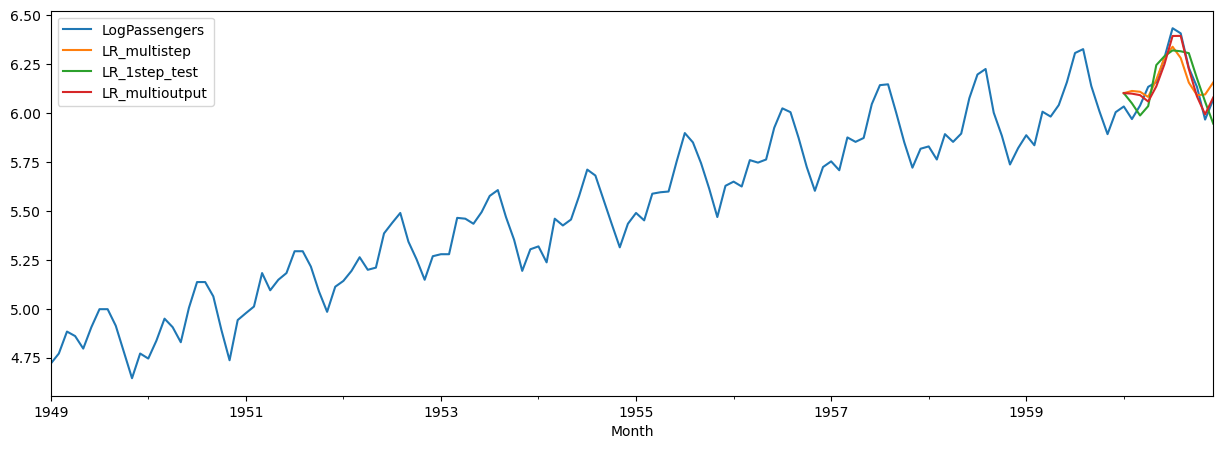

In [113]:
df[['LogPassengers','LR_multistep','LR_1step_test','LR_multioutput']].plot(figsize = (15,5));

In [120]:
'''multioutput looks the best - peak captured best'''

'multioutput looks the best - peak captured best'

In [119]:
#MAPE - just checking other metrics
mape_1 = mean_absolute_percentage_error(Ytest, multistep_predictions)
print("multi-step MAPE:", mape_1)

mape_2 = mean_absolute_percentage_error(Ytest, df.loc[test_idx, 'LR_multioutput'])
print("multi-output MAPE:", mape_2)

multi-step MAPE: 0.012229325023475348
multi-output MAPE: 0.0071789244750398


In [121]:
''' multi out mape is bit better '''

' multi out mape is bit better '

## testing other models

In [124]:
def one_step_and_multistep_forecast(model, name):
    model.fit(Xtrain, Ytrain)
    print("One-step forecast:", name)

    # 1 step forecast
    df.loc[train_idx, f'{name}_1step_train'] = model.predict(Xtrain)
    df.loc[test_idx, f'{name}_1step_test'] = model.predict(Xtest)

    #generate multi-step forecast
    multistep_predictions =[]
    last_x = Xtest[0]

    while len(multistep_predictions) < Ntest:
        p = model.predict(last_x.reshape(1,-1))[0]

        multistep_predictions.append(p)

        last_x = np.roll(last_x,-1)
        last_x[-1] = p

    df.loc[test_idx, f'{name}_multistep_test'] = multistep_predictions

    mape = mean_absolute_percentage_error(Ytest, multistep_predictions)
    print("Test MAPE (multistep):", mape)

    cols = [
        'LogPassengers',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test'
    ]
    
    df[cols].plot(figsize =(15,5));    

One-step forecast: SVR
Test MAPE (multistep): 0.017529446164230467


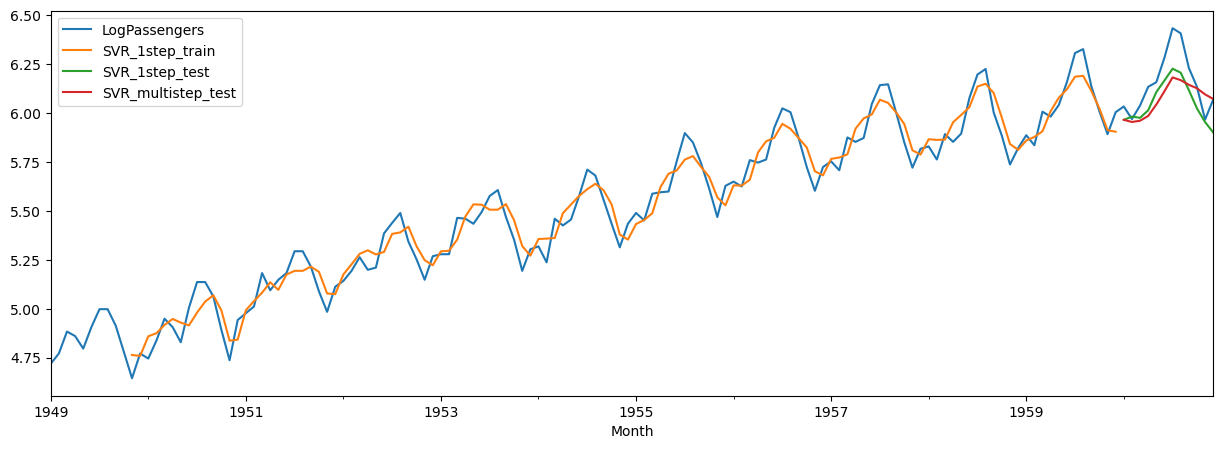

In [125]:
one_step_and_multistep_forecast(SVR(),"SVR")

One-step forecast: RF
Test MAPE (multistep): 0.028012087885941412


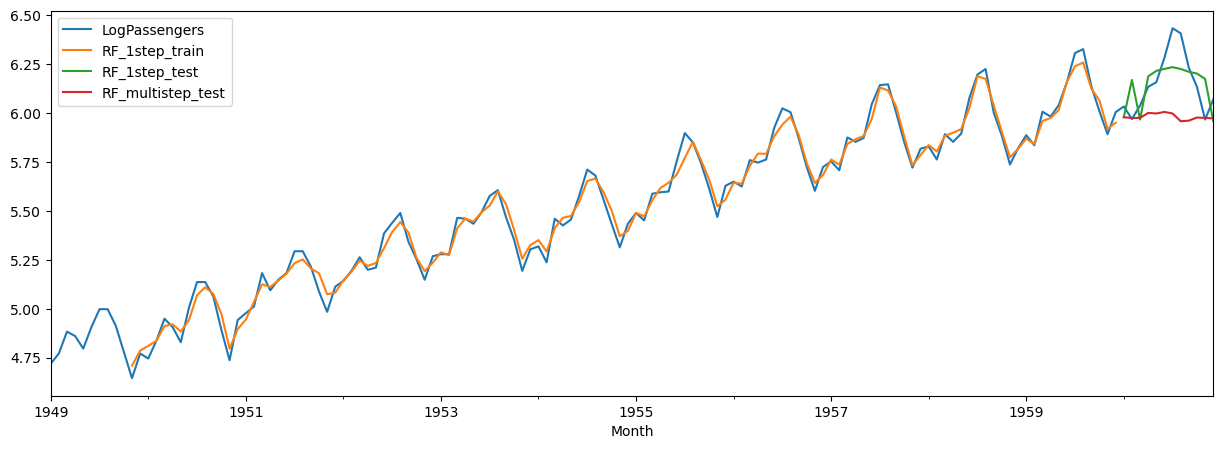

In [128]:
one_step_and_multistep_forecast(RandomForestRegressor(),"RF")

In [129]:
''' train set fitting very well typical of random forest'''

' train set fitting very well typical of random forest'

In [130]:
def multi_output_forecast(model, name):
    
    model.fit(Xtrain_m, Ytrain_m)
    
    # 1 step forecast
    
    df.loc[test_idx, f'{name}_multioutput'] = model.predict(Xtest_m).flatten()

    mape = mean_absolute_percentage_error(Ytest, df.loc[test_idx, f'{name}_multioutput'])
    print("Test MAPE (multi-output):", mape)
    
    #
    cols = [
        'LogPassengers',
        f'{name}_1step_train',
        f'{name}_1step_test',
        f'{name}_multistep_test',
        f'{name}_multioutput'
    ]
    
    df[cols].plot(figsize =(15,5));    

In [135]:
# multi_output_forecast(SVR(),"SVR")
''' this will throw error since it cannot handle multi-output'''

' this will throw error since it cannot handle multi-output'

Test MAPE (multi-output): 0.015281155096457222


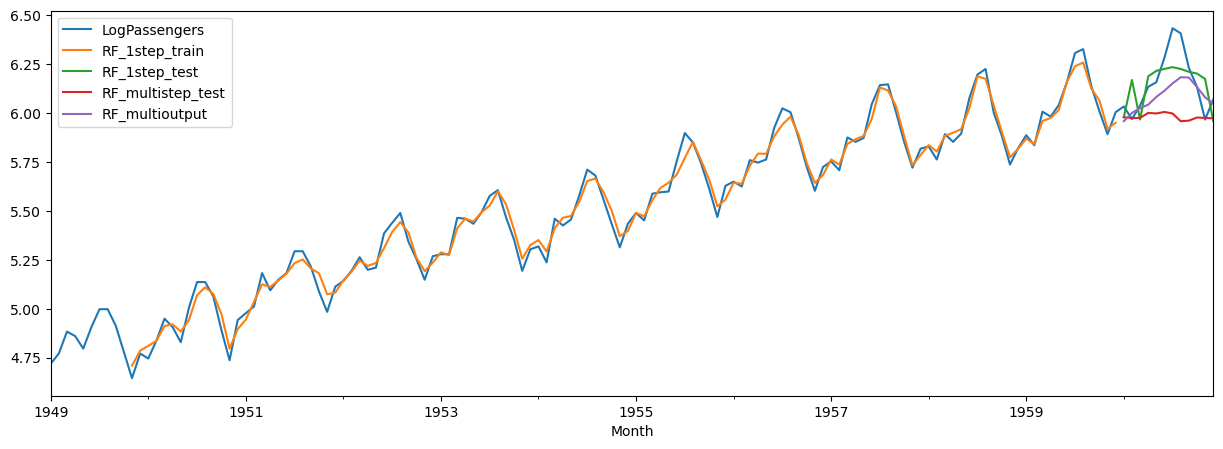

In [132]:
multi_output_forecast(RandomForestRegressor(),"RF")

In [134]:
''' doesnt perform too well'''

' doesnt perform too well'

# working with differencing